# RECONSTRUCT THE RESULT OF TRANING PROCESS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os

LAST_CKPT = '/content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch/checkpoints/last_tracknetv5_5frame.pth'

OUTPUT_DIR = '/content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch/training_plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LR                  = 1e-4
LR_DECAY_EPOCHS     = [25, 31]
EARLY_STOP_PATIENCE = 8

print(' Config ready')
print(f'   Checkpoint : {LAST_CKPT}')
print(f'   Output dir : {OUTPUT_DIR}')

✅ Config ready
   Checkpoint : /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch/checkpoints/last_tracknetv5_5frame.pth
   Output dir : /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch/training_plots


In [ ]:
import torch, numpy as np

assert os.path.exists(LAST_CKPT), f'Checkpoint not found: {LAST_CKPT}'

ckpt    = torch.load(LAST_CKPT, map_location='cpu')
history = ckpt['history']
best_f1 = ckpt['best_f1']
n_epoch = ckpt['epoch']

train_loss = history['train_loss']
val_loss   = history['val_loss']
val_acc    = history['val_acc']
val_prec   = history['val_prec']
val_rec    = history['val_rec']
val_f1     = history['val_f1']

epochs = list(range(1, len(train_loss) + 1))

best_ep = int(np.argmax(val_f1)) + 1

print(' History loaded')
print(f'   Total epochs trained : {len(epochs)}')
print(f'   Last epoch           : {n_epoch}')
print(f'   Best F1              : {best_f1:.4f}  @ epoch {best_ep}')
print(f'   Final train loss     : {train_loss[-1]:.4f}')
print(f'   Final val   loss     : {val_loss[-1]:.4f}')
print(f'   Final val   F1       : {val_f1[-1]:.4f}')
print(f'   Final val   Acc      : {val_acc[-1]:.4f}')
print(f'   Final val   Prec     : {val_prec[-1]:.4f}')
print(f'   Final val   Recall   : {val_rec[-1]:.4f}')

✅ History loaded
   Total epochs trained : 26
   Last epoch           : 26
   Best F1              : 0.9734  @ epoch 18
   Final train loss     : 0.0001
   Final val   loss     : 0.0003
   Final val   F1       : 0.9733
   Final val   Acc      : 0.9528
   Final val   Prec     : 0.9755
   Final val   Recall   : 0.9711


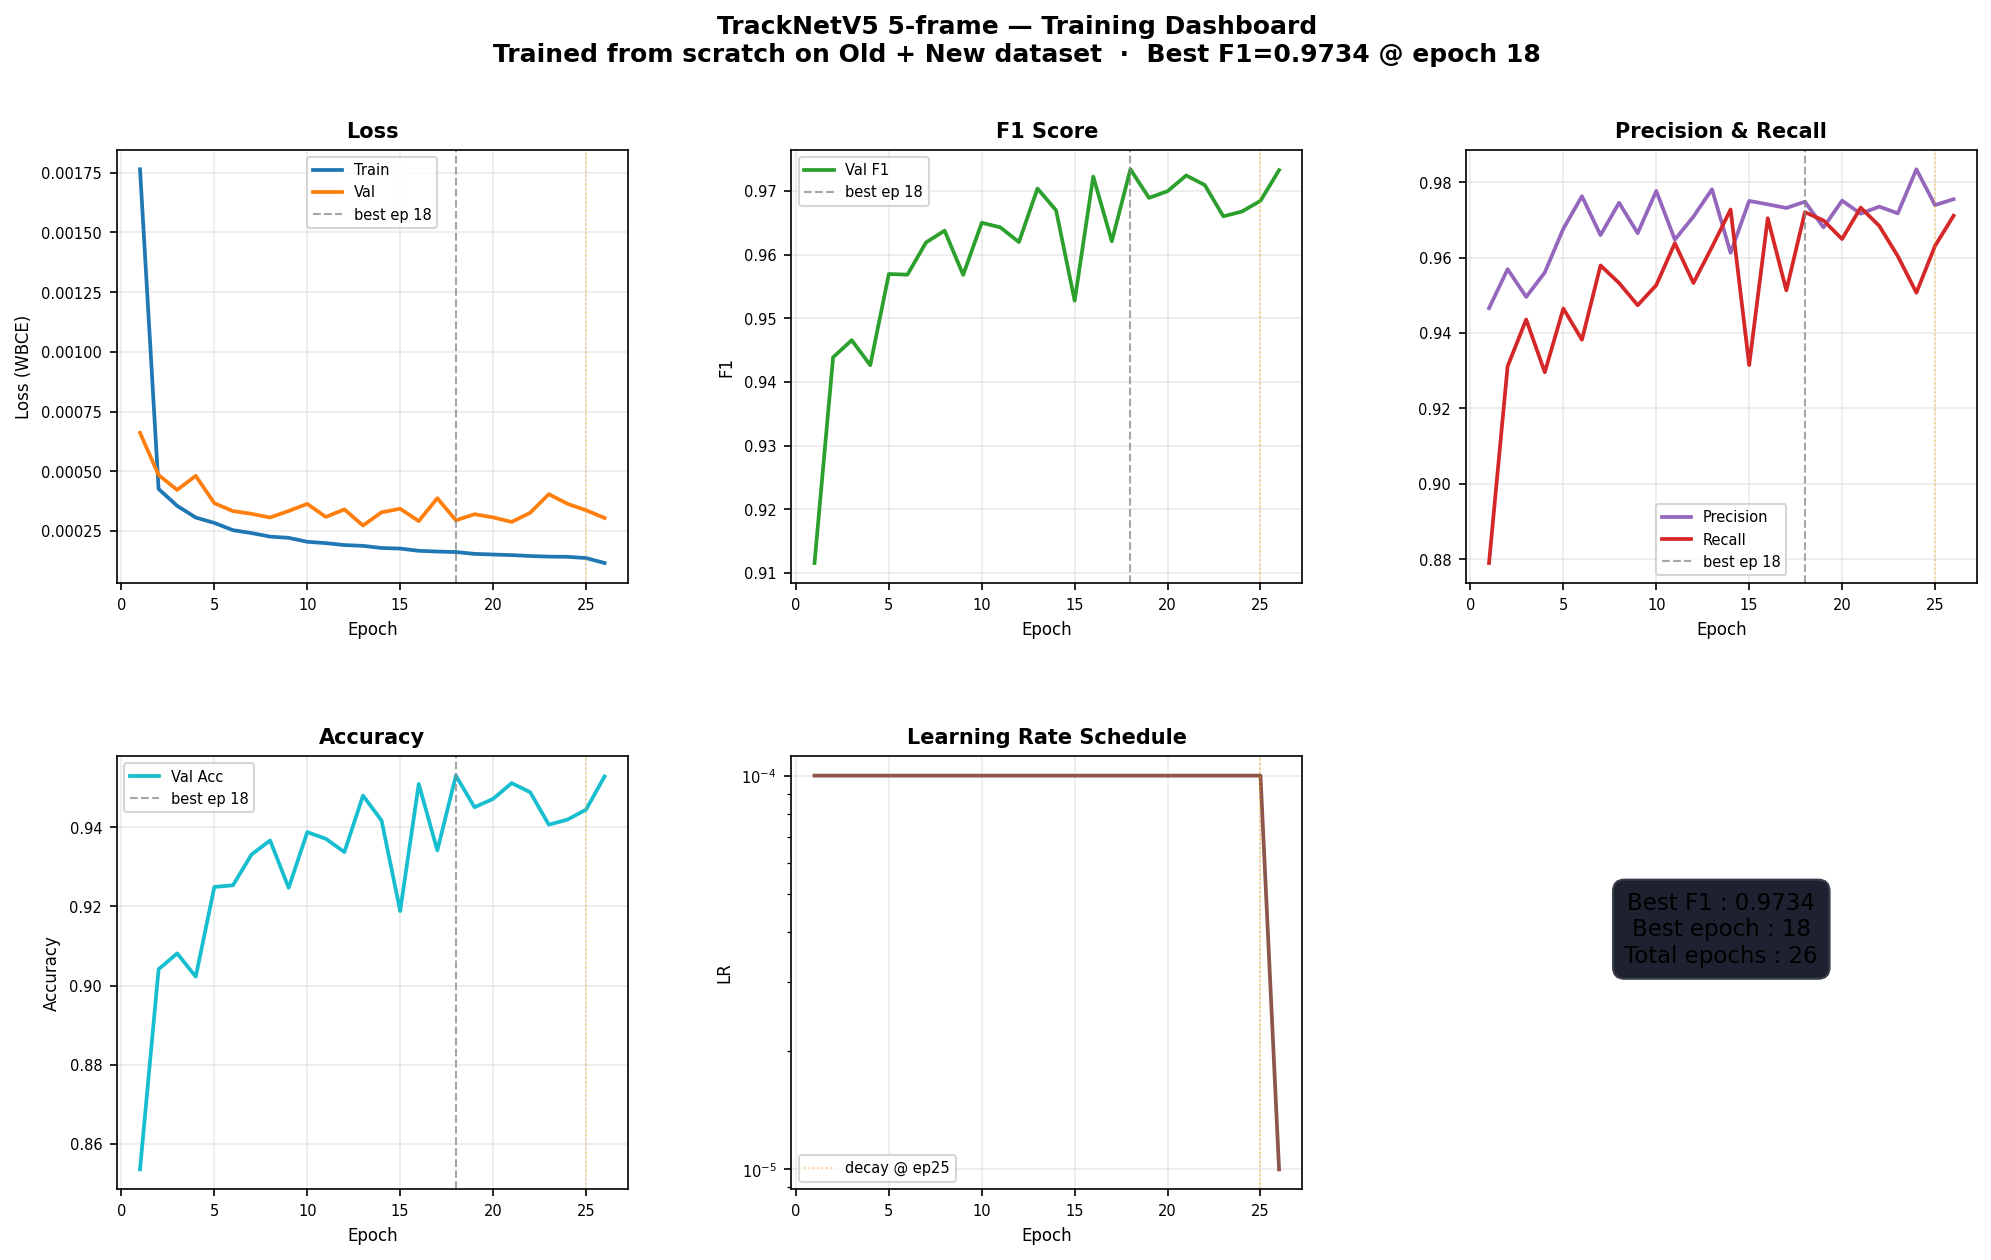

✅ Saved → /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch/training_plots/fig1_training_dashboard.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({'figure.dpi': 150, 'font.size': 9})

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)
axs = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

def _plot(ax, title, series, colors, ylabel=''):
    for (lbl, vals), col in zip(series, colors):
        ax.plot(epochs, vals, label=lbl, color=col, lw=1.8)
    ax.axvline(best_ep, color='grey', ls='--', lw=1.0,
               alpha=0.7, label=f'best ep {best_ep}')
    for d_ep in LR_DECAY_EPOCHS:
        if d_ep <= len(epochs):
            ax.axvline(d_ep, color='orange', ls=':', lw=0.8, alpha=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=7)

_plot(axs[0], 'Loss',
      [('Train', train_loss), ('Val', val_loss)],
      ['tab:blue', 'tab:orange'], 'Loss (WBCE)')

_plot(axs[1], 'F1 Score',
      [('Val F1', val_f1)],
      ['tab:green'], 'F1')

_plot(axs[2], 'Precision & Recall',
      [('Precision', val_prec), ('Recall', val_rec)],
      ['tab:purple', 'tab:red'])

_plot(axs[3], 'Accuracy',
      [('Val Acc', val_acc)],
      ['tab:cyan'], 'Accuracy')

ax = axs[4]
lr_hist, lr = [], LR
for ep in epochs:
    lr_hist.append(lr)
    if ep in LR_DECAY_EPOCHS:
        lr *= 0.1
ax.plot(epochs, lr_hist, color='tab:brown', lw=1.8)
ax.set_yscale('log')
for d_ep in LR_DECAY_EPOCHS:
    if d_ep <= len(epochs):
        ax.axvline(d_ep, color='orange', ls=':', lw=0.8, alpha=0.6,
                   label=f'decay @ ep{d_ep}')
ax.set_title('Learning Rate Schedule', fontsize=10, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=8)
ax.set_ylabel('LR', fontsize=8)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.25)
ax.tick_params(labelsize=7)

axs[5].axis('off')
axs[5].text(0.5, 0.6,
            f'Best F1 : {best_f1:.4f}\nBest epoch : {best_ep}\nTotal epochs : {len(epochs)}',
            ha='center', va='center', fontsize=11,
            transform=axs[5].transAxes,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#1e2130',
                      edgecolor='#3a3d4a'))

plt.suptitle(
    f'TrackNetV5 5-frame — Training Dashboard\n'
    f'Trained from scratch on Old + New dataset  ·  '
    f'Best F1={best_f1:.4f} @ epoch {best_ep}',
    fontsize=12, fontweight='bold'
)

path1 = f'{OUTPUT_DIR}/fig1_training_dashboard.png'
plt.savefig(path1, dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved → {path1}')

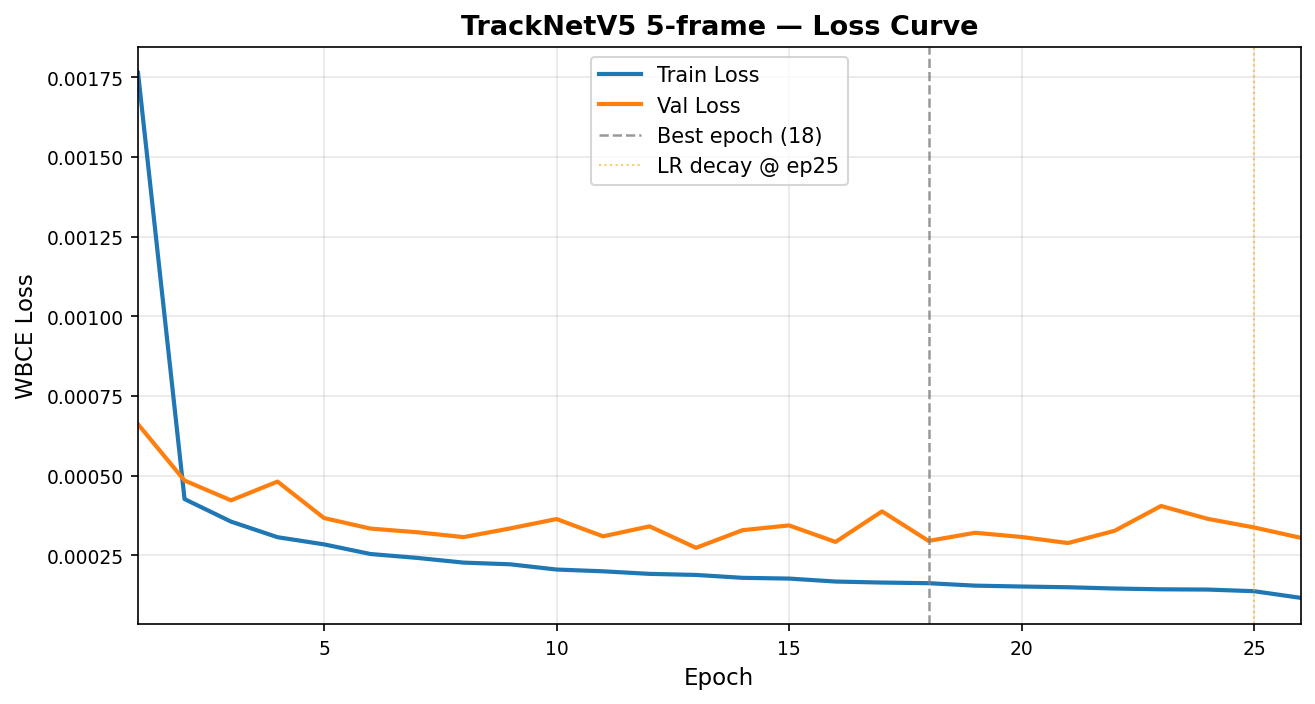

✅ Saved → /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch/training_plots/fig2_loss_curve.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, train_loss, color='tab:blue', lw=2, label='Train Loss')
ax.plot(epochs, val_loss,   color='tab:orange', lw=2, label='Val Loss')

ax.axvline(best_ep, color='grey', ls='--', lw=1.2,
           alpha=0.8, label=f'Best epoch ({best_ep})')
for d_ep in LR_DECAY_EPOCHS:
    if d_ep <= len(epochs):
        ax.axvline(d_ep, color='orange', ls=':', lw=1.0, alpha=0.6,
                   label=f'LR decay @ ep{d_ep}')

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('WBCE Loss', fontsize=11)
ax.set_title('TrackNetV5 5-frame — Loss Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(epochs))

path2 = f'{OUTPUT_DIR}/fig2_loss_curve.png'
plt.savefig(path2, dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved → {path2}')

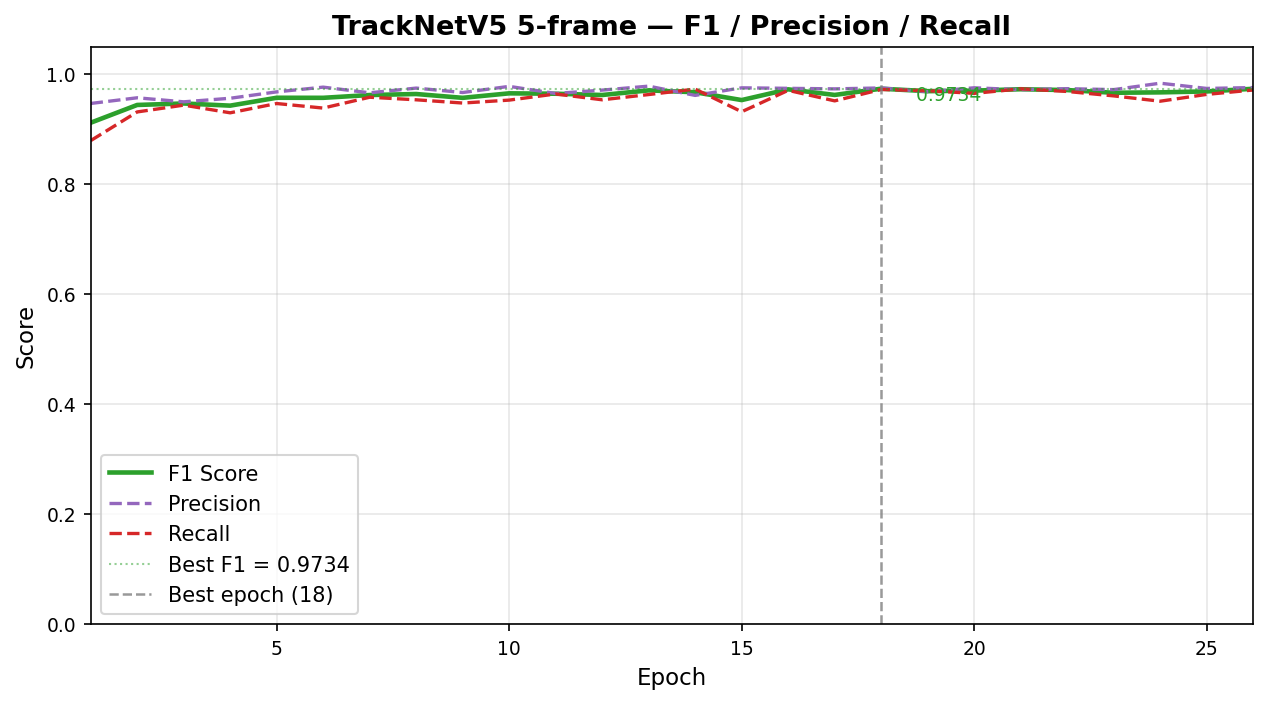

✅ Saved → /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch/training_plots/fig3_f1_precision_recall.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, val_f1,   color='tab:green',  lw=2.2, label='F1 Score')
ax.plot(epochs, val_prec, color='tab:purple', lw=1.6, ls='--', label='Precision')
ax.plot(epochs, val_rec,  color='tab:red',    lw=1.6, ls='--', label='Recall')

ax.axhline(best_f1, color='tab:green', ls=':', lw=1.0, alpha=0.5,
           label=f'Best F1 = {best_f1:.4f}')
ax.axvline(best_ep, color='grey', ls='--', lw=1.2, alpha=0.8,
           label=f'Best epoch ({best_ep})')

ax.annotate(f'  {best_f1:.4f}',
            xy=(best_ep, best_f1),
            fontsize=9, color='tab:green',
            xytext=(best_ep + 0.5, best_f1 - 0.02))

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('TrackNetV5 5-frame — F1 / Precision / Recall',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(epochs))

path3 = f'{OUTPUT_DIR}/fig3_f1_precision_recall.png'
plt.savefig(path3, dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved → {path3}')

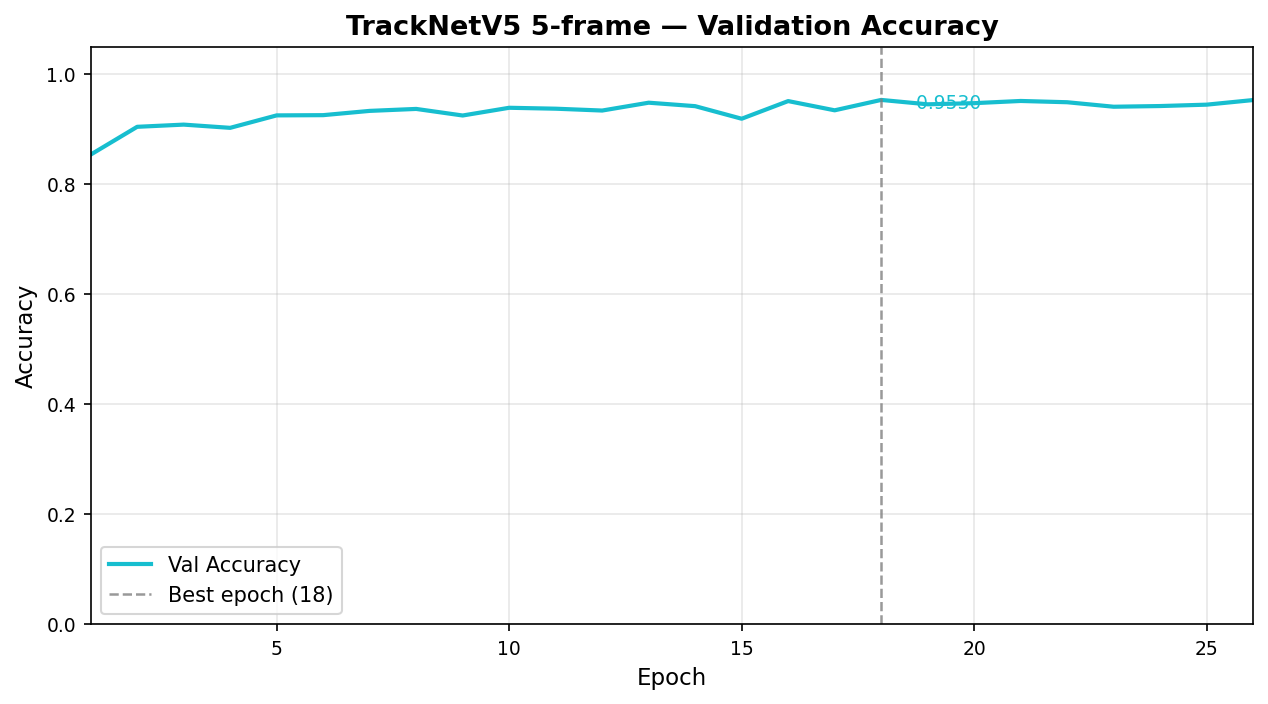

✅ Saved → /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch/training_plots/fig4_accuracy.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, val_acc, color='tab:cyan', lw=2, label='Val Accuracy')
ax.axvline(best_ep, color='grey', ls='--', lw=1.2,
           alpha=0.8, label=f'Best epoch ({best_ep})')

best_acc = val_acc[best_ep - 1]
ax.annotate(f'  {best_acc:.4f}',
            xy=(best_ep, best_acc),
            fontsize=9, color='tab:cyan',
            xytext=(best_ep + 0.5, best_acc - 0.015))

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('TrackNetV5 5-frame — Validation Accuracy',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(epochs))

path4 = f'{OUTPUT_DIR}/fig4_accuracy.png'
plt.savefig(path4, dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved → {path4}')

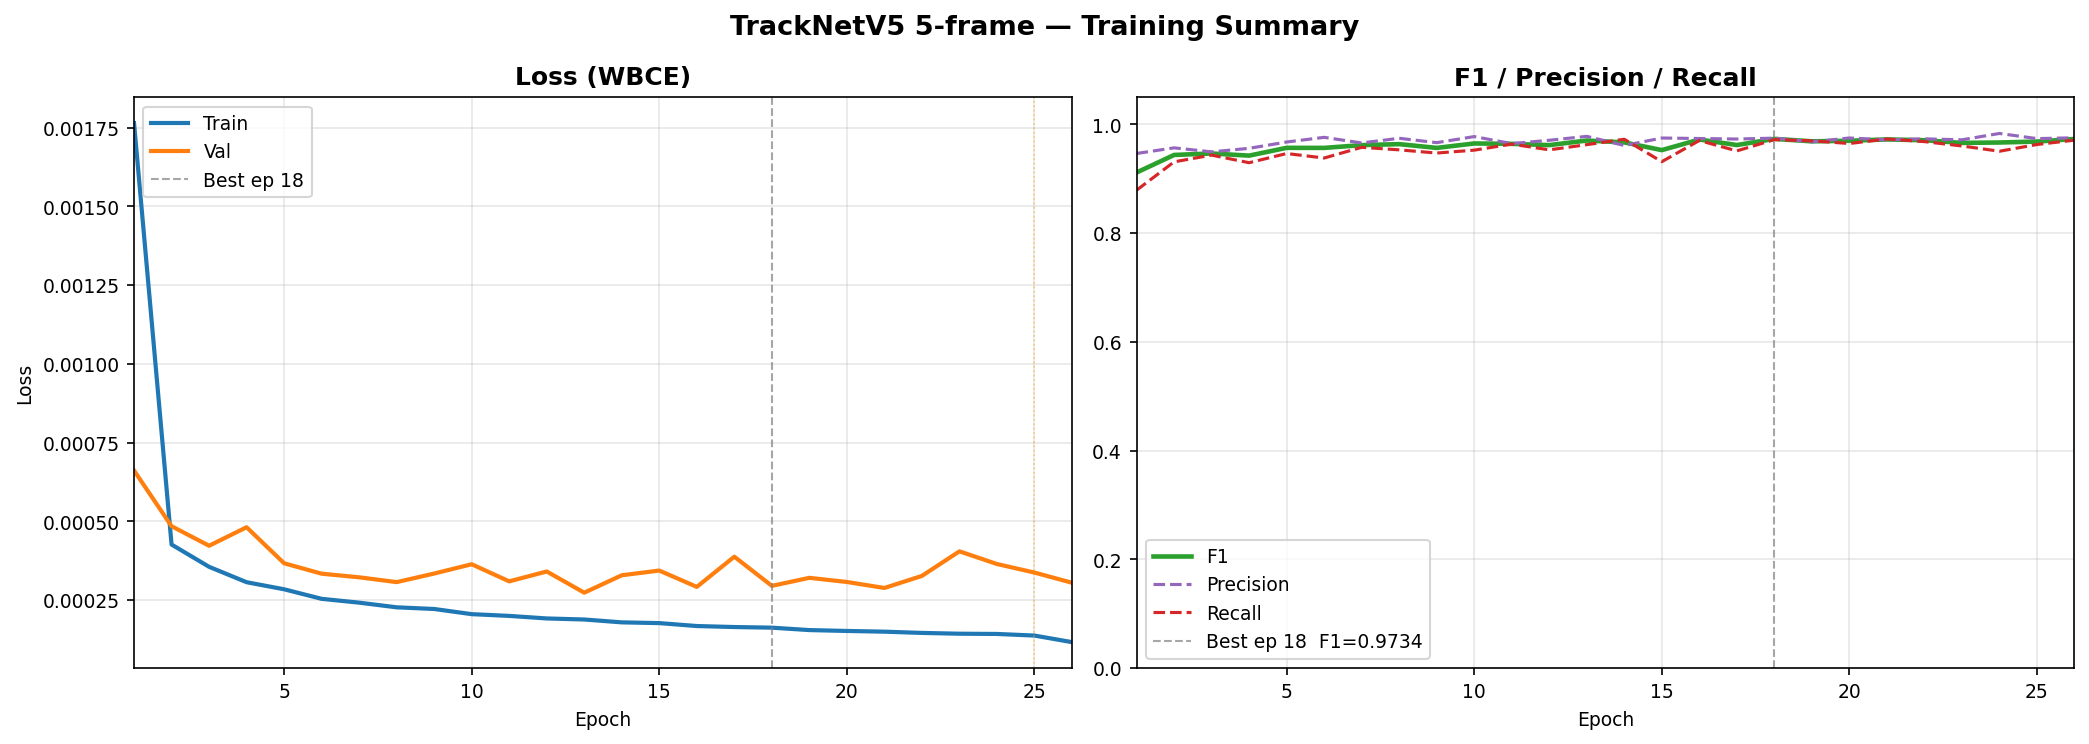

✅ Saved → /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_5frame_scratch/training_plots/fig5_summary_2panel.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_loss, color='tab:blue',   lw=2, label='Train')
ax1.plot(epochs, val_loss,   color='tab:orange', lw=2, label='Val')
ax1.axvline(best_ep, color='grey', ls='--', lw=1.0, alpha=0.7,
            label=f'Best ep {best_ep}')
for d_ep in LR_DECAY_EPOCHS:
    if d_ep <= len(epochs):
        ax1.axvline(d_ep, color='orange', ls=':', lw=0.8, alpha=0.5)
ax1.set_title('Loss (WBCE)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, len(epochs))

ax2.plot(epochs, val_f1,   color='tab:green',  lw=2.2, label='F1')
ax2.plot(epochs, val_prec, color='tab:purple', lw=1.5, ls='--', label='Precision')
ax2.plot(epochs, val_rec,  color='tab:red',    lw=1.5, ls='--', label='Recall')
ax2.axvline(best_ep, color='grey', ls='--', lw=1.0, alpha=0.7,
            label=f'Best ep {best_ep}  F1={best_f1:.4f}')
ax2.set_ylim(0, 1.05)
ax2.set_title('F1 / Precision / Recall', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, len(epochs))

plt.suptitle('TrackNetV5 5-frame — Training Summary',
             fontsize=13, fontweight='bold')
plt.tight_layout()

path5 = f'{OUTPUT_DIR}/fig5_summary_2panel.png'
plt.savefig(path5, dpi=150, bbox_inches='tight')
plt.show()
print(f' Saved → {path5}')

In [ ]:
print()
print('=' * 80)
print('FULL TRAINING HISTORY — epoch by epoch')
print('=' * 80)
print(f"{'Ep':>4}  {'TrainLoss':>10}  {'ValLoss':>9}  "
      f"{'Acc':>7}  {'Prec':>7}  {'Recall':>7}  {'F1':>7}  {'Note':>12}")
print('-' * 80)

for i, ep in enumerate(epochs):
    note = ''
    if ep == best_ep:
        note = '← BEST F1'
    elif ep in LR_DECAY_EPOCHS:
        note = 'LR decay'
    print(f"{ep:>4}  {train_loss[i]:>10.5f}  {val_loss[i]:>9.5f}  "
          f"{val_acc[i]:>7.4f}  {val_prec[i]:>7.4f}  "
          f"{val_rec[i]:>7.4f}  {val_f1[i]:>7.4f}  {note:>12}")

print('=' * 80)
print(f'Best F1: {best_f1:.4f} @ epoch {best_ep}')
print()
print('Files saved:')
for p in [path1, path2, path3, path4, path5]:
    print(f'  {p}')


FULL TRAINING HISTORY — epoch by epoch
  Ep   TrainLoss    ValLoss      Acc     Prec   Recall       F1          Note
--------------------------------------------------------------------------------
   1     0.00176    0.00066   0.8536   0.9466   0.8790   0.9115              
   2     0.00043    0.00048   0.9041   0.9569   0.9312   0.9439              
   3     0.00036    0.00042   0.9081   0.9496   0.9436   0.9465              
   4     0.00031    0.00048   0.9022   0.9560   0.9296   0.9426              
   5     0.00028    0.00037   0.9249   0.9677   0.9465   0.9570              
   6     0.00025    0.00033   0.9253   0.9763   0.9382   0.9568              
   7     0.00024    0.00032   0.9331   0.9659   0.9579   0.9619              
   8     0.00023    0.00031   0.9366   0.9745   0.9532   0.9638              
   9     0.00022    0.00033   0.9247   0.9665   0.9474   0.9568              
  10     0.00020    0.00036   0.9387   0.9777   0.9527   0.9650              
  11     0.00020    0